In [1]:
import sys  
sys.path.insert(1, '../')

import re
import gc
import numpy as np
import segyio
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from devito import TimeFunction, Eq, solve, Operator, configuration

from scratch.util import plot_seis_data, plot_rec_src, read_radex_picks
from examples.seismic.acoustic import AcousticWaveSolver
from examples.seismic import AcquisitionGeometry, Model, plot_velocity

configuration['platform'] = 'nvidiaX'
configuration['compiler'] = 'pgcc'
configuration['language'] = 'openacc'

In [2]:
def create_velocity_model(depths, velocities, max_depth, dz):
    """
    Create a velocity model from depth-velocity pairs with linear interpolation.
    For depths above the first known point, uses the first known velocity.
    For depths below the last known point, uses the last known velocity.
    
    Parameters:
    depths (array-like): Array of depths in meters (must be increasing)
    velocities (array-like): Array of velocities at corresponding depths (m/s)
    max_depth (float): Maximum depth of the model (m)
    dz (float): Vertical grid spacing (m)
    
    Returns:
    tuple: (depth_array, velocity_model) where both are numpy arrays
    """
    # Convert inputs to numpy arrays
    depths = np.asarray(depths, dtype=np.float32)
    velocities = np.asarray(velocities, dtype=np.float32)
    
    # Verify input
    if len(depths) != len(velocities):
        raise ValueError("depths and velocities must have same length")
    if not np.all(depths[1:] > depths[:-1]):
        raise ValueError("depths must be strictly increasing")
    if depths[0] < 0:
        raise ValueError("depths cannot be negative")
    
    # Create depth array for output model
    model_depths = np.arange(0, max_depth, dz)
    
    # Create interpolator
    # kind='linear' does linear interpolation
    # fill_value='extrapolate' would extrapolate, but we want constant values beyond data range
    interpolator = interp1d(depths, velocities, 
                           kind='nearest',
                           fill_value=(velocities[0], velocities[-1]),
                           bounds_error=False)
    
    # Interpolate velocities
    velocity_model = interpolator(model_depths)
    
    return model_depths, velocity_model

In [41]:
spacing = (0.4, 0.4)
size = (200, 50)
shape = tuple(int(i/j) for i, j in zip(size, spacing))
#speeds
vdf = pd.read_excel("../../data/VSP_Gypsum_data/ВСП_скорости_ИТОГ.xlsx", sheet_name="Skv_E_S", header=0)
vdf = vdf[vdf["Vs (7 точек)"].notna()]
d, vp = create_velocity_model(vdf["DEPTH"], vdf["Vs (7 точек)"], size[1], spacing[1])
vp = np.tile(vp, (shape[0], 1))/1000
#left square
vp[int(50/spacing[0]):int(54/spacing[0]+spacing[0]),int(28/spacing[1]):int(32/spacing[1]+spacing[1])] = 1e-10
vp[int(100/spacing[0]):int(104/spacing[0]+spacing[0]),int(28/spacing[1]):int(32/spacing[1]+spacing[1])] = 1e-10
vp[int(129/spacing[0]):int(133/spacing[0]+spacing[0]),int(28/spacing[1]):int(32/spacing[1]+spacing[1])] = 1e-10
vp[int(153/spacing[0]):int(157/spacing[0]+spacing[0]),int(28/spacing[1]):int(32/spacing[1]+spacing[1])] = 1e-10
vp[int(167/spacing[0]):int(171/spacing[0]+spacing[0]),int(28/spacing[1]):int(32/spacing[1]+spacing[1])] = 1e-10


x_pos = np.arange(0,size[0]+2, 2)
device_coordinates = np.vstack((x_pos, np.zeros_like(x_pos))).T


model = Model(vp=vp, origin=(0,0), shape=shape, spacing=spacing,
              space_order=2, nbl=500, bcs="damp")

Operator `initdamp` ran in 0.02 s


### if you want to save model

In [ ]:
# vsp_speed = pd.DataFrame(columns=["cdp", "depth", "vel"])
# for i in range(0,101):
#     temp_df = pd.DataFrame({"cdp": np.ones(vdf.shape[0])*i, "depth": vdf["DEPTH"], "vel": vdf["Vs (7 точек)"]})
#     temp_df["cdp"] = temp_df["cdp"].astype(int)
#     vsp_speed = pd.concat((vsp_speed, temp_df), ignore_index=True)
# vsp_speed.to_csv('../../results/2d_acoustic/VSP_Gypsum/speeds.csv', sep="\t", index=False)


/tmp/ipykernel_17978/1522640295.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  vsp_speed = pd.concat((vsp_speed, temp_df), ignore_index=True)


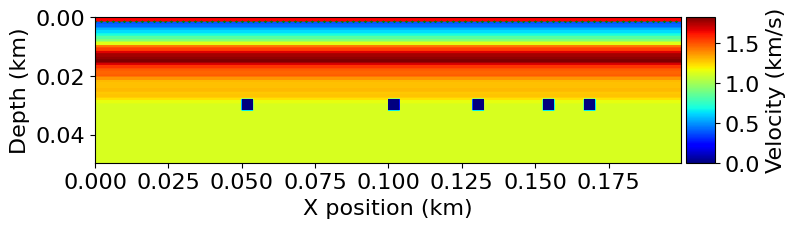

In [42]:
plot_velocity(model, device_coordinates+[1,0], device_coordinates)

In [ ]:
for i, src_coords in enumerate(device_coordinates + [1,0]):
        print('Source - ', i, '; Coordinate - ', src_coords)
        geometry = AcquisitionGeometry(model, device_coordinates, src_coords, 0, 500, f0=0.120, src_type='Ricker')
        
        # солвер
        solver = AcousticWaveSolver(model, geometry, space_order=2)
        
        # оператор
        print('Starting operator')
        rec, u, summary = solver.forward() # tau summary
        print('finished operator')
        # выгрузка в sgy
        dt_r = 0.5
        # inheader = segysak.segy.segy_header_scrape(scenario+'/Vs_smooth_2D')
        rec = rec.resample(dt=dt_r)
        path = '../../results/2d_acoustic/VSP_Gypsum/Wider model'
        segyio.tools.from_array2D(path +'/2d_VSP_gypsum_SRC-'+str(int(src_coords[0]))+'.sgy', rec.data.T, dt=dt_r*10**3)
        with segyio.open(path+'/2d_VSP_gypsum_SRC-'+str(int(src_coords[0]))+'.sgy', 'r+') as f:
            for j in range(len(f.header)):
                f.header[j] = {#segyio.TraceField.SourceGroupScalar : -100,
                               segyio.TraceField.SourceX : int(src_coords[0]),
                               segyio.TraceField.GroupX : np.array(rec.coordinates.data[j,0], dtype = int)
                    # segyio.TraceField.CDP: j,
                    #            segyio.TraceField.CDP_X: np.array(inheader['CDP_X'][j]*10),
                    #            segyio.TraceField.CDP_Y: np.array(inheader['CDP_Y'][j]*10),
                               # segyio.TraceField.ReceiverGroupElevation: np.array(df_ins['Z'][j], dtype = int),
                               # segyio.TraceField.ElevationScalar : 1,
                              }
        gc.collect()

Source -  0 ; Coordinate -  [0 0]
Starting operator


Operator `Forward` ran in 0.28 s


finished operator


/home/artem/miniconda3/envs/devito/lib/python3.12/site-packages/segyio/utils.py:18: RuntimeWarning: Implicit conversion to contiguous array
  warnings.warn(msg, RuntimeWarning)
